# Карта рисков и трассировка

Ноутбук читает сводную таблицу рисков из `risks.md` и список требований из
`functional.md`, проверяет ссылки между ними, рисует карту рисков `risk-map.png`, собирает
файл трассировки `traceability.md` и вписывает данные в объёмную схему
`requirements-graph.html`.

Запуск: из папки `docs/requirements`, все ячейки по порядку. После любой правки
`risks.md` или `functional.md` ноутбук запускается заново.

In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

HERE = Path.cwd()
FUNCTIONAL = HERE / "functional.md"
RISKS = HERE / "risks.md"
assert FUNCTIONAL.exists() and RISKS.exists(), "запускать из папки docs/requirements"

FR_ID = r"FR-[A-Z]+-\d{2}"

## 1. Требования из `functional.md`

Заголовок требования имеет вид `#### FR-<ГРУППА>-<NN>. Название`, объём и приоритет
записаны в строке полей под текстом.

In [2]:
functional_text = FUNCTIONAL.read_text(encoding="utf-8")
rows = []
for block in re.split(r"^#### ", functional_text, flags=re.M)[1:]:
    m = re.match(rf"({FR_ID})\. (.+)", block.splitlines()[0])
    if not m:
        continue
    rows.append({
        "id": m.group(1),
        "название": m.group(2).strip(),
        "объём": re.search(r"Объём: (семестр|продукт)", block).group(1),
        "приоритет": int(re.search(r"Приоритет: (\d)", block).group(1)),
    })
fr = pd.DataFrame(rows).set_index("id")
print(len(fr), "требований:", fr["объём"].value_counts().to_dict())

68 требований: {'семестр': 51, 'продукт': 17}


## 2. Риски из `risks.md`

Берутся строки сводной таблицы (раздел 2), номера требований выделяются из столбцов мер.

In [3]:
risks_text = RISKS.read_text(encoding="utf-8")
cols = ["id", "риск", "вид", "В", "У", "ВУ", "меры_семестр", "меры_продукт"]
records = []
for line in risks_text.splitlines():
    if re.match(r"\| R[SP]-\d{2} \|", line):
        cells = [c.strip() for c in line.strip().strip("|").split("|")]
        records.append(dict(zip(cols, cells)))
risks = pd.DataFrame(records).set_index("id")
for c in ["В", "У", "ВУ"]:
    risks[c] = risks[c].astype(int)
risks["fr_семестр"] = risks["меры_семестр"].apply(lambda s: re.findall(FR_ID, s))
risks["fr_продукт"] = risks["меры_продукт"].apply(lambda s: re.findall(FR_ID, s))
risks["есть_меры_в_семестре"] = risks["меры_семестр"] != ""
risks["зона"] = pd.cut(risks["ВУ"], [0, 4, 9, 25], labels=["низкая", "средняя", "высокая"])
print(len(risks), "рисков:", risks["вид"].value_counts().to_dict())
risks[["риск", "вид", "В", "У", "ВУ", "зона"]]

30 рисков: {'стратегия': 18, 'проект': 12}


,риск,вид,В,У,ВУ,зона
id,,,,,,
RS-01,"Скачок implied yield на рынке с TWAP-оракулом,...",стратегия,2,5,10,высокая
RS-02,"Депег USDe и переключение мета-оракула, ликвид...",стратегия,1,5,5,средняя
RS-03,Ставка займа выше доходности PT,стратегия,3,3,9,средняя
RS-04,Ликвидация хеджа Boros,стратегия,3,3,9,средняя
RS-05,"Хедж движется не так, как цена PT (базисный риск)",стратегия,4,2,8,средняя
RS-06,Нет ликвидности для выхода,стратегия,3,3,9,средняя
RS-07,Капитал нужен в другой сети,стратегия,2,4,8,средняя
RS-08,Перекат хеджа Boros невозможен или дорог,стратегия,2,2,4,низкая
RS-09,Данные программы устарели или неверны,стратегия,3,4,12,высокая


## 3. Проверки

Ноутбук ищет расхождения, которые руками легко пропустить: неверное произведение В×У,
ссылку на несуществующее требование, требование не того объёма в столбце мер, риск без
описания в разделах 3–4.

In [4]:
problems = []
for rid, r in risks.iterrows():
    if r["В"] * r["У"] != r["ВУ"]:
        problems.append(f"{rid}: В×У = {r['В'] * r['У']}, в таблице {r['ВУ']}")
    if f"### {rid}." not in risks_text:
        problems.append(f"{rid}: нет описания в разделах 3–4")
    for f in r["fr_семестр"] + r["fr_продукт"]:
        if f not in fr.index:
            problems.append(f"{rid}: требования {f} нет в functional.md")
    for f in r["fr_семестр"]:
        if f in fr.index and fr.loc[f, "объём"] != "семестр":
            problems.append(f"{rid}: {f} стоит в мерах семестра, но его объём «продукт»")
    for f in r["fr_продукт"]:
        if f in fr.index and fr.loc[f, "объём"] != "продукт":
            problems.append(f"{rid}: {f} стоит в мерах продукта, но его объём «семестр»")
print("Расхождений нет." if not problems else "\n".join(problems))

gap = risks[(risks["зона"] == "высокая") & ~risks["есть_меры_в_семестре"]]
print("\nВысокая зона без мер в семестре (в risks.md должна быть записана причина):")
print(gap[["риск", "ВУ"]].to_string() if len(gap) else "нет")

Расхождений нет.

Высокая зона без мер в семестре (в risks.md должна быть записана причина):
                                               риск  ВУ
id                                                     
RS-14                   Ошибка реального исполнения  15
RP-08  Живой рынок погашается раньше конца семестра  15


## 4. Карта рисков

По горизонтали вероятность, по вертикали ущерб, цвет клетки задан величиной В×У.
Круг означает риск стратегии, квадрат риск проекта; закрашенный значок говорит, что у риска
есть меры в семестре. Шкалы описаны в `risks.md`, раздел 1.

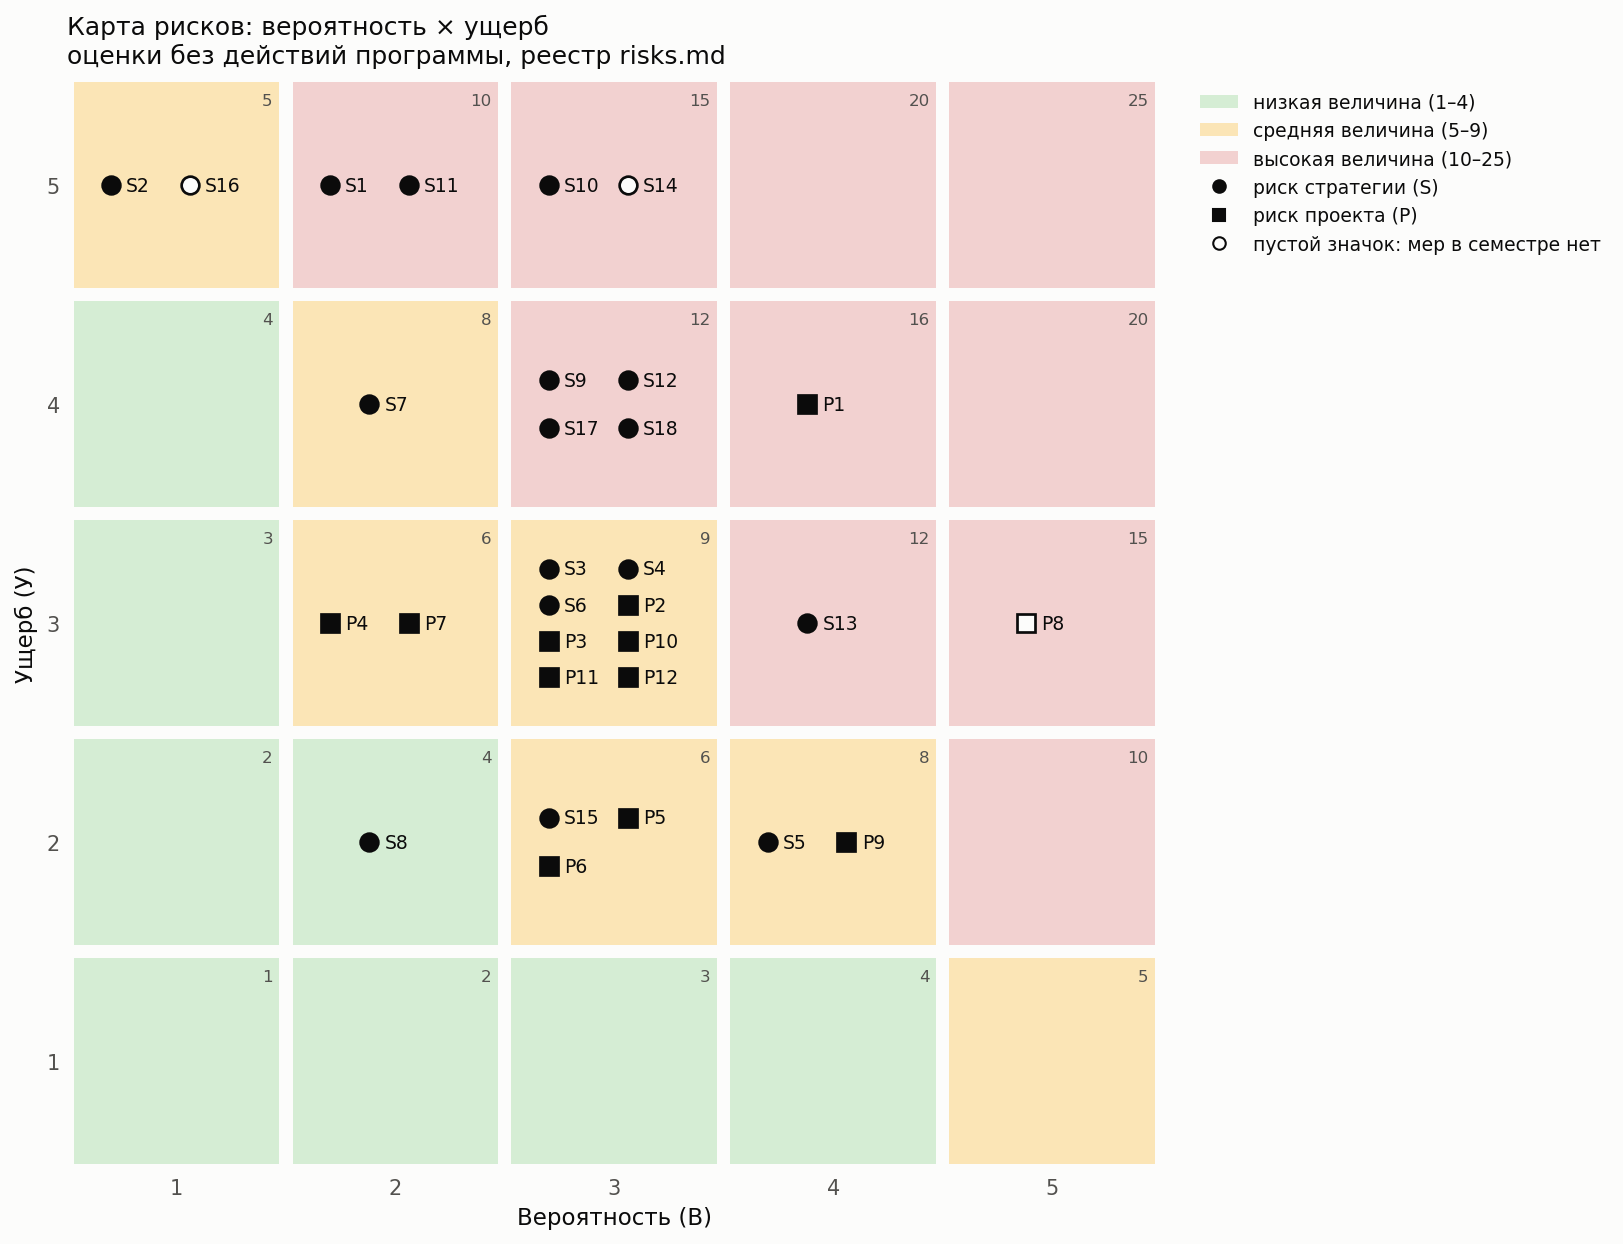

In [5]:
SURFACE, INK, INK_2 = "#fcfcfb", "#0b0b0b", "#52514e"
ZONES = {  # цвета статусной палитры, приглушённые до фона клетки
    "низкая": ("#0ca30c", 0.16, "1–4"),
    "средняя": ("#fab219", 0.30, "5–9"),
    "высокая": ("#d03b3b", 0.22, "10–25"),
}

def zone(score):
    return "низкая" if score <= 4 else "средняя" if score <= 9 else "высокая"

def label(rid):
    return ("S" if rid.startswith("RS") else "P") + str(int(rid[3:]))

fig, ax = plt.subplots(figsize=(10, 8.4), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

gap_px = 0.03  # зазор между клетками цвета фона
for p in range(1, 6):
    for d in range(1, 6):
        color, alpha, _ = ZONES[zone(p * d)]
        ax.add_patch(Rectangle((p - 0.5 + gap_px, d - 0.5 + gap_px), 1 - 2 * gap_px,
                               1 - 2 * gap_px, facecolor=color, alpha=alpha, linewidth=0))
        ax.text(p + 0.44, d + 0.42, str(p * d), ha="right", va="top", fontsize=8, color=INK_2)

order = [(0 if i.startswith("RS") else 1, int(i[3:])) for i in risks.index]
for (p, d), cell in risks.assign(порядок=order).sort_values("порядок").groupby(["В", "У"]):
    # значки клетки в два столбца, строки центрированы по высоте клетки
    n = len(cell)
    if n == 1:
        slots = [(p - 0.12, d)]
    else:
        nrows = math.ceil(n / 2)
        h = min(0.22, 0.66 / nrows)
        y0 = d + (nrows - 1) * h / 2
        slots = [(p - 0.30 + (i % 2) * 0.36, y0 - (i // 2) * h) for i in range(n)]
    for (x, y), (rid, r) in zip(slots, cell.iterrows()):
        marker = "o" if r["вид"] == "стратегия" else "s"
        face = INK if r["есть_меры_в_семестре"] else SURFACE
        ax.plot(x, y, marker=marker, markersize=8.5, markerfacecolor=face,
                markeredgecolor=INK, markeredgewidth=1.3, linestyle="none", zorder=3)
        ax.text(x + 0.07, y, label(rid), ha="left", va="center", fontsize=9, color=INK, zorder=4)

ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
ax.set_xlabel("Вероятность (В)", color=INK, fontsize=11)
ax.set_ylabel("Ущерб (У)", color=INK, fontsize=11)
ax.tick_params(colors=INK_2, length=0, labelsize=10)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_aspect("equal")
ax.set_title("Карта рисков: вероятность × ущерб\n"
             "оценки без действий программы, реестр risks.md",
             color=INK, fontsize=12, loc="left")

handles = [Patch(facecolor=c, alpha=a, label=f"{name} величина ({rng})")
           for name, (c, a, rng) in ZONES.items()]
handles += [
    Line2D([], [], marker="o", color=INK, markerfacecolor=INK, linestyle="none", label="риск стратегии (S)"),
    Line2D([], [], marker="s", color=INK, markerfacecolor=INK, linestyle="none", label="риск проекта (P)"),
    Line2D([], [], marker="o", color=INK, markerfacecolor=SURFACE, linestyle="none",
           label="пустой значок: мер в семестре нет"),
]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False,
          fontsize=9, labelcolor=INK)
fig.tight_layout()
fig.savefig(HERE / "risk-map.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## 5. Трассировка

Собирает `traceability.md`: для каждого риска требования, которые его закрывают, и для
каждого требования риски, которые оно закрывает. Столбец с тестами появится вместе с
тестами.

In [6]:
by_fr = {f: [] for f in fr.index}
for rid, r in risks.iterrows():
    for f in r["fr_семестр"] + r["fr_продукт"]:
        if f in by_fr:
            by_fr[f].append(rid)

out = [
    "# Трассировка: риски и требования",
    "",
    "Файл собирает ноутбук `risk-map.ipynb` из `risks.md` и `functional.md`. Руками не "
    "править: правки вносятся в исходные файлы, затем ноутбук запускается заново.",
    "",
    "## 1. Риск → требования",
    "",
    "Риски по убыванию величины. Для рисков проекта меры приведены текстом.",
    "",
    "| Риск | В×У | Зона | Меры в семестре | Меры в продукте |",
    "|---|---|---|---|---|",
]
for rid, r in risks.sort_values(["ВУ", "В"], ascending=False).iterrows():
    sem = r["меры_семестр"] or "нет"
    prod = r["меры_продукт"] or "нет"
    out.append(f"| {rid}. {r['риск']} | {r['ВУ']} | {r['зона']} | {sem} | {prod} |")

out += [
    "",
    "## 2. Требование → риски",
    "",
    "«Нет» в последнем столбце не значит, что требование лишнее: режимы, вывод и часть "
    "расчётов следуют из назначения программы, а не из отдельного риска.",
    "",
    "| Требование | Объём | Приоритет | Закрывает риски |",
    "|---|---|---|---|",
]
for f, r in fr.iterrows():
    linked = ", ".join(by_fr[f]) or "нет"
    out.append(f"| {f}. {r['название']} | {r['объём']} | {r['приоритет']} | {linked} |")

covered = {s: sum(1 for f in fr.index[fr["объём"] == s] if by_fr[f]) for s in ["семестр", "продукт"]}
total = fr["объём"].value_counts()
out += [
    "",
    "## 3. Сводка",
    "",
    f"- Требований семестра, закрывающих хотя бы один риск: {covered['семестр']} из {total['семестр']}.",
    f"- Требований продукта, закрывающих хотя бы один риск: {covered['продукт']} из {total['продукт']}.",
    f"- Рисков высокой зоны без мер в семестре: {len(gap)}"
    + (f" ({', '.join(gap.index)})." if len(gap) else "."),
    "",
]
with open(HERE / "traceability.md", "w", encoding="utf-8", newline="\n") as fh:
    fh.write("\n".join(out))
print("\n".join(out[-5:]))


- Требований семестра, закрывающих хотя бы один риск: 44 из 51.
- Требований продукта, закрывающих хотя бы один риск: 12 из 17.
- Рисков высокой зоны без мер в семестре: 2 (RS-14, RP-08).



## 6. Объёмная схема `requirements-graph.html`

Собирает данные схемы: шаги процесса из таблицы `diagrams.md` (раздел 6), требования с
формулировкой, проверкой и связями из `functional.md`, риски из таблицы выше. Проверяет,
что каждое требование привязано ровно к одному основному шагу, и вписывает данные в страницу
между метками `GRAPH-DATA-BEGIN` и `GRAPH-DATA-END`.

In [7]:
import json

DIAGRAMS = HERE / "diagrams.md"
GRAPH = HERE / "requirements-graph.html"

# шаги процесса
steps = []
for line in DIAGRAMS.read_text(encoding="utf-8").splitlines():
    if re.match(r"\| S\d \|", line):
        c = [x.strip() for x in line.strip().strip("|").split("|")]
        steps.append({"id": c[0], "name": c[1], "what": c[2],
                      "fr": re.findall(FR_ID, c[3]), "also": re.findall(FR_ID, c[4])})

# подробности требований: формулировка до строки «- Объём:», дальше поля списком
details = {}
for block in re.split(r"^#### ", functional_text, flags=re.M)[1:]:
    lines = block.splitlines()
    m = re.match(rf"({FR_ID})\. (.+)", lines[0])
    if not m:
        continue
    body = lines[1:]
    k = next(i for i, l in enumerate(body) if l.startswith("- Объём:"))
    text = "\n".join(body[:k]).strip()
    text = re.sub(r"\n(?!\n|- )", " ", text)  # склеить строки абзаца, пункты списка оставить
    items, cur = [], None
    for l in body[k:]:
        if l.startswith("- "):
            cur = l[2:].strip(); items.append(cur)
        elif l.startswith("  ") and items:
            items[-1] += " " + l.strip()
        elif l.startswith("#"):
            break
    field = lambda name: next((i[len(name) + 2:] for i in items if i.startswith(name + ":")), "")
    head = field("Объём")
    feas = re.search(r"Реализуемость: (.+?)\. Оценка:", head)
    est = re.search(r"Оценка: ([SML])", head)
    details[m.group(1)] = {
        "text": text,
        "feasibility": feas.group(1) if feas else "",
        "estimate": est.group(1) if est else "",
        "check": field("Проверка"),
        "links": re.findall(FR_ID, field("Связи")),
    }

# проверки привязки к шагам
graph_problems = []
primary = [f for s in steps for f in s["fr"]]
for f in fr.index:
    n = primary.count(f)
    if n != 1:
        graph_problems.append(f"{f}: основных шагов {n}, нужен ровно один")
for s in steps:
    for f in s["fr"] + s["also"]:
        if f not in fr.index:
            graph_problems.append(f"{s['id']}: требования {f} нет в functional.md")
    for f in s["also"]:
        if f in s["fr"]:
            graph_problems.append(f"{s['id']}: {f} стоит и в основных, и во вторых")
print(len(steps), "шагов;", "расхождений нет." if not graph_problems else "\n".join(graph_problems))

steps_of = {f: [s["id"] for s in steps if f in s["fr"]] + [s["id"] for s in steps if f in s["also"]]
            for f in fr.index}
version = lambda text: re.search(r"\*\*Версия:\*\* ([\d.]+)", text).group(1)
graph = {
    "sources": f"functional.md {version(functional_text)}, risks.md {version(risks_text)}, diagrams.md",
    "steps": steps,
    "fr": [{"id": f, "title": r["название"], "scope": r["объём"], "priority": int(r["приоритет"]),
            "steps": steps_of[f], **details[f]} for f, r in fr.iterrows()],
    "risks": [{"id": rid, "title": r["риск"], "kind": r["вид"], "p": int(r["В"]), "d": int(r["У"]),
               "score": int(r["ВУ"]), "zone": str(r["зона"]), "fr": r["fr_семестр"], "frp": r["fr_продукт"],
               "sem_text": r["меры_семестр"]} for rid, r in risks.iterrows()],
}

page = GRAPH.read_text(encoding="utf-8")
begin, end = "/*GRAPH-DATA-BEGIN*/", "/*GRAPH-DATA-END*/"
i, j = page.index(begin) + len(begin), page.index(end)
payload = json.dumps(graph, ensure_ascii=False, indent=1).replace("</", "<\\/")
page = page[:i] + "\nconst DATA = " + payload + ";\n" + page[j:]
with open(GRAPH, "w", encoding="utf-8", newline="\n") as fh:
    fh.write(page)
print(f"В схему записано: шагов {len(steps)}, требований {len(graph['fr'])}, рисков {len(graph['risks'])}.")

9 шагов; расхождений нет.
В схему записано: шагов 9, требований 68, рисков 30.
